# Electoral Analytics Hybrid Model (FiveThirtyEight-inspired)
This notebook builds a simplified electoral forecasting model with:
- Elasticity calculation
- Machine Learning (XGBoost)
- Monte Carlo Simulation


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

## 1. Simulated Electoral Data

In [2]:
np.random.seed(42)

n = 500

data = pd.DataFrame({
'national_swing': np.random.normal(0, 5, n),
'income': np.random.normal(50, 10, n),
'education': np.random.normal(12, 2, n),
'turnout': np.random.uniform(40, 80, n)
})

# True relationship
data['vote_share'] = (
    0.5 * data['national_swing'] +
    0.2 * data['income'] +
    0.3 * data['education'] +
    np.random.normal(0, 2, n)
)

data.head()

,national_swing,income,education,turnout,vote_share
0,2.483571,59.261775,14.798711,50.792829,14.392001
1,-0.691322,69.094166,13.849267,73.001976,15.374418
2,3.238443,36.014324,12.119261,59.930227,10.070014
3,7.615149,55.629692,10.706126,43.082331,18.431237
4,-1.170767,43.493574,13.396447,42.342037,15.597295


## 2. Electoral Elasticity

In [3]:
from sklearn.linear_model import LinearRegression

X = data[['national_swing']]
y = data['vote_share']

model = LinearRegression().fit(X, y)
elasticity = model.coef_[0]

print(f'Estimated Elasticity: {elasticity:.3f}')

Estimated Elasticity: 0.435


## 3. Machine Learning Model

In [4]:
features = ['national_swing', 'income', 'education', 'turnout']
X = data[features]
y = data['vote_share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor()
model.fit(X_train, y_train)

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f'RMSE: {rmse:.2f}')

RMSE: 2.46


## 4. Monte Carlo Simulation

In [5]:
simulations = []

for i in range(1000):
    noise = np.random.normal(0, 2, len(X_test))
    sim_pred = model.predict(X_test) + noise
    simulations.append(sim_pred.mean())

simulations = np.array(simulations)

prob_win = np.mean(simulations > 50)

print(f'Probability of winning (>50% vote): {prob_win:.2f}')

Probability of winning (>50% vote): 0.00


## 5. Simulation Distribution

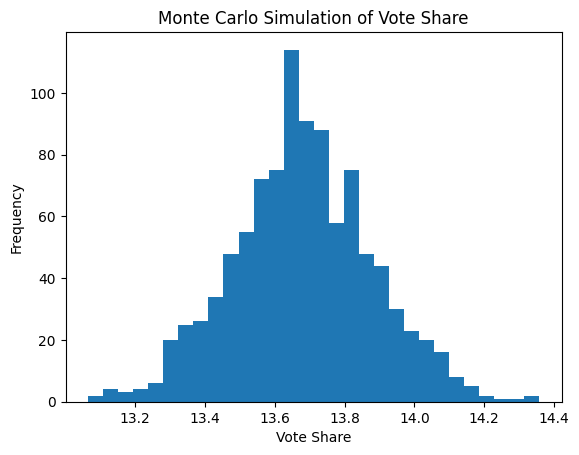

In [6]:
plt.hist(simulations, bins=30)
plt.title('Monte Carlo Simulation of Vote Share')
plt.xlabel('Vote Share')
plt.ylabel('Frequency')
plt.show()